# Bilinear / Control-Affine Koopman Terms

Default Koopman-with-control in KoopmanGraph is **additive**. The library uses
**row-state** latents (trailing dim = latent size):

$$
z_{t+1} = z_t K^\top + u_t B
$$

with learnable `B` of shape `(control_dim, latent_dim)`. Classical column-state
DMDc / linear predictors instead write

$$
z_{t+1} = A z_t + B_{\mathrm{col}} u_t
$$

with $B_{\mathrm{col}}$ of shape `(latent_dim, control_dim)`
[@Proctor2016DMDc; @Korda2018]. Identifying $A\equiv K$ and
$B_{\mathrm{col}}\equiv B^\top$ recovers the column form of the library map:

$$
z_{t+1} = K z_t + B^\top u_t.
$$

For **control-affine** systems, Bruder et al. show that a (possibly infinite)
bilinear Koopman realization always exists, whereas a linear realization need
not exist [@Bruder2021]. In continuous time they write bilinear realizations as

$$
\dot z_i
  = \sum_j a_{ij} z_j
  + \sum_j b_{ij} u_j
  + \sum_{j,k} h_{ijk}\, z_k u_j.
$$

This notebook uses the library's discrete finite-dimensional surrogate
`control_mode="bilinear"` (row-state; not an automatic time-discretization of
Bruder's continuous Def. II.1 for arbitrary step size):

$$
z_{t+1}
  = z_t K^\top
  + u_t B
  + \sum_i u_t[i]\,(z_t N_i^\top),
$$

Equivalently, in column form,

$$
z_{t+1} = K z_t + B^\top u_t + \sum_i u_t[i]\, N_i z_t,
$$

with each `N_i` of shape `(latent_dim, latent_dim)`.

> **Primary question.** On a synthetic control-affine latent system, does bilinear
> mode close a one-step loss floor that additive-only control cannot close?

> **Applied question.** On networked SIR with **multiplicative contact reduction**
> $\mathrm{infection}=\beta(1-u_t)\,S\cdot\mathrm{force}$, does bilinear improve
> fit versus additive when free dynamics `K` are held fixed from the
> pre-intervention window?


## Methodology

1. **Synthetic plant.** Known `(K, N)` with `B = 0`; freeze `K`; train only control
   factors. **Structural** claim.
2. **Epidemic plant.** `EpidemicNetworkBenchmark` with
   `expose_intervention_control=True` (contact reduction after a 25% uncontrolled prefix).
3. **Applied operator fit.** Least-squares `K` on the uncontrolled prefix; freeze it;
   train additive `B` vs bilinear `N` on post-onset steps in physical `(S,I,R)`
   coordinates (shared across nodes).
4. **SIR diagnostics (full-state, teacher-forced).**
   - Pre-/post-onset one-step MSE bars (gap should appear after onset).
   - One-step full-state MSE vs time (re-anchored on truth each tick).
   - Path-averaged one-step RMSE vs path length `H` on intervention origins
     (not open-loop compounding; long open-loop is a different stress test).
5. **Scope.** Stylized NPIs, not case data; not closed-loop RL (see notebook 15).
   Aggregate mean-`I(t)` is **not** used as a success metric here (it need not
   inherit the full-state ranking).

CI uses a short epoch budget; interactive runs use a fuller demo budget.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

from koopman_graph.datasets import EpidemicNetworkBenchmark
from koopman_graph.operators import KoopmanOperator

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
SYNTH_EPOCHS = 80 if CI else 500
EPI_STEPS = 200 if CI else 1000
_ = torch.manual_seed(0)


## Synthetic control-affine recovery

Known free dynamics `K` and bilinear factors `N` (`B = 0`). The plant is simulated
in the same row-state convention as the operator,

$$
z \leftarrow z K^\top + u B + u_0\,(z N_0^\top),
$$

then we freeze `K` and train only control parameters: additive mode must absorb
the state–control term into `u B` and leave a large one-step floor; bilinear
mode recovers the coupling down to numerical noise.


In [2]:
true_k = torch.diag(torch.tensor([0.85, 0.9]))
true_n = torch.tensor([[[0.0, 0.8], [-0.7, 0.0]]])
true_b = torch.zeros(1, 2)

z0 = torch.tensor([1.0, -0.5])
controls = torch.linspace(-1.0, 1.0, 40)
states = [z0]
z = z0.clone()
for value in controls[:-1]:
    u = torch.tensor([float(value)])
    z = z @ true_k.T + u @ true_b + u[0] * (z @ true_n[0].T)
    states.append(z.clone())


def fit_control_mode(mode: str) -> tuple[KoopmanOperator, float]:
    operator = KoopmanOperator(
        2, control_dim=1, control_mode=mode, init_mode="identity"
    )
    with torch.no_grad():
        kwargs = {"control_matrix": torch.zeros(1, 2)}
        if mode == "bilinear":
            kwargs["bilinear_matrices"] = torch.zeros_like(true_n)
        operator.set_dense_matrix(true_k, **kwargs)
    operator.K.requires_grad_(False)  # dense parameterization
    opt = torch.optim.Adam([p for p in operator.parameters() if p.requires_grad], lr=5e-2)
    final = 0.0
    for _ in range(SYNTH_EPOCHS):
        opt.zero_grad()
        loss = torch.zeros(())
        for t, value in enumerate(controls[:-1]):
            u = torch.tensor([float(value)])
            pred = operator(states[t], control=u)
            loss = loss + (pred - states[t + 1]).square().mean()
        loss.backward()
        opt.step()
        final = float(loss.detach())
    return operator, final


op_add, loss_add = fit_control_mode("additive")
op_bi, loss_bi = fit_control_mode("bilinear")
print(f"Additive one-step MSE : {loss_add:.4e}")
print(f"Bilinear one-step MSE : {loss_bi:.4e}")
assert loss_bi < loss_add
if not CI:
    assert loss_bi < 1e-3
    assert loss_add > 5e-2


Additive one-step MSE : 4.7455e+00
Bilinear one-step MSE : 2.3453e-14


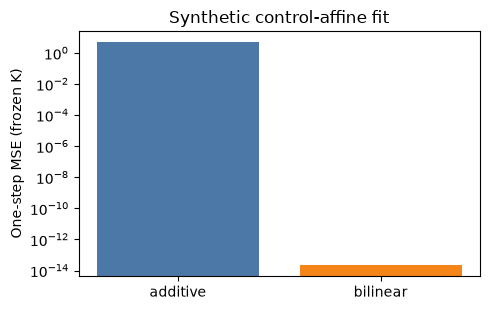

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["additive", "bilinear"], [loss_add, loss_bi], color=["#4C78A8", "#F58518"])
ax.set_ylabel("One-step MSE (frozen K)")
ax.set_title("Synthetic control-affine fit")
ax.set_yscale("log")
fig.tight_layout()
plt.show()


## Networked SIR with contact-reduction control

Node states are fractions $(S_i,I_i,R_i)$ with $S_i+I_i+R_i=1$. Let
$\mathrm{Adj}$ be the **row-normalized** contact adjacency and define the
force of infection

$$
\mathrm{force}_i = (\mathrm{Adj}\, I)_i.
$$

With intervention intensity $u_t\in[0,1]$ (fractional contact reduction /
stylized NPI), one discrete step is

$$
\begin{aligned}
\mathrm{infection}_i &= \beta (1 - u_t)\, S_i\,\mathrm{force}_i,\\
\mathrm{recovered}_i &= \gamma I_i,\\
I_i &\leftarrow \bigl[I_i + \mathrm{infection}_i - \mathrm{recovered}_i\bigr]_+,\\
R_i &\leftarrow \bigl[R_i + \mathrm{recovered}_i\bigr]_+,\\
S_i &\leftarrow \bigl[1 - I_i - R_i\bigr]_+.
\end{aligned}
$$

Expanding the infection term shows the control-affine structure
$\beta S_i\mathrm{force}_i - u_t\cdot(\beta S_i\mathrm{force}_i)$. Control
multiplies a **state-dependent** channel. With free dynamics `K` fixed from the
uncontrolled prefix, additive `B` alone is structurally limited.

Figures below report **full-state teacher-forced** residuals under this protocol:
the bilinear gap appears **after onset**. Claims are restricted to that metric
family; open-loop multi-step compounding and aggregate incidence curves are out of
scope for the applied claim.


Full-state one-step MSE (frozen K)
  pre-onset  additive=1.2206e-04  bilinear=1.2206e-04
  post-onset additive=1.2841e-03  bilinear=1.1086e-03  relative improvement=13.7%
Mean post-onset MSE gap (additive − bilinear): 1.7552e-04  (positive ⇒ bilinear lower)
Path-averaged one-step RMSE (full state, intervention origins)
  H= 1: additive=3.6618e-02  bilinear=3.3081e-02
  H= 3: additive=3.6605e-02  bilinear=3.3115e-02
  H= 5: additive=3.6588e-02  bilinear=3.3154e-02
  H=10: additive=3.6528e-02  bilinear=3.3290e-02


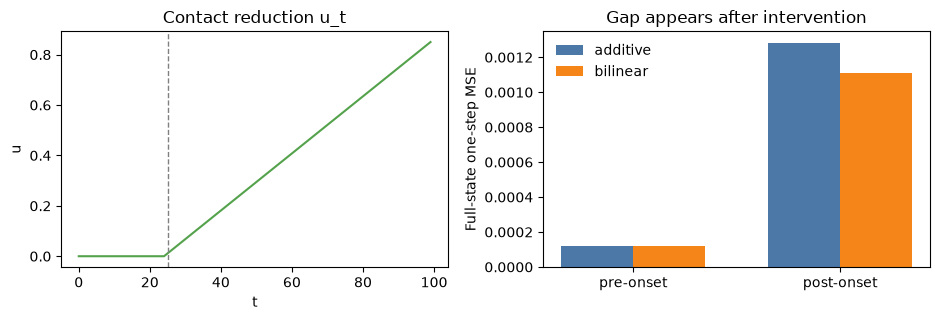

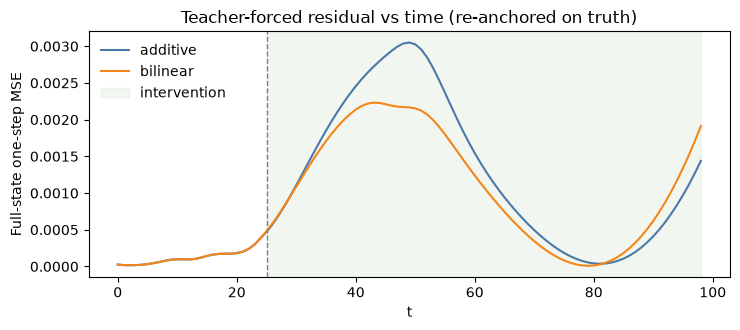

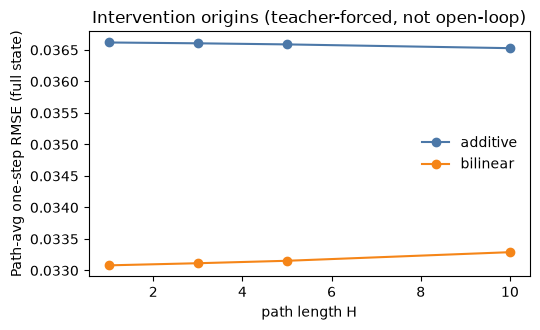

In [4]:
T = 60 if CI else 100
ONSET_FRAC = 0.25
onset = int(ONSET_FRAC * T)
horizons = (1, 2, 3) if CI else (1, 3, 5, 10)
schedule = EpidemicNetworkBenchmark.default_intervention_schedule(
    T, onset_fraction=ONSET_FRAC, max_reduction=0.85
)
seq = EpidemicNetworkBenchmark.generate(
    num_nodes=24 if CI else 36,
    num_timesteps=T,
    topology="ring",
    beta=0.5,
    gamma=0.1,
    seed=3,
    expose_intervention_control=True,
    intervention=schedule,
)
assert seq.control_inputs is not None

zs = [seq[t].x for t in range(len(seq) - 1)]
znext = [seq[t + 1].x for t in range(len(seq) - 1)]
us = [seq.control_inputs[t] for t in range(len(seq) - 1)]

# Free dynamics from uncontrolled prefix.
X = torch.cat(zs[: max(onset, 5)], dim=0)
Y = torch.cat(znext[: max(onset, 5)], dim=0)
k0 = torch.linalg.lstsq(X, Y).solution.T

pre_idxs = list(range(0, onset))
post_idxs = list(range(onset, len(zs)))


def fit_epidemic_control(mode: str) -> KoopmanOperator:
    operator = KoopmanOperator(
        3, control_dim=1, control_mode=mode, init_mode="identity"
    )
    with torch.no_grad():
        kwargs: dict = {"control_matrix": torch.zeros(1, 3)}
        if mode == "bilinear":
            kwargs["bilinear_matrices"] = torch.zeros(1, 3, 3)
        operator.set_dense_matrix(k0, **kwargs)
    operator.K.requires_grad_(False)  # dense parameterization
    opt = torch.optim.Adam(
        [p for p in operator.parameters() if p.requires_grad], lr=3e-2
    )
    for _ in range(EPI_STEPS):
        opt.zero_grad()
        loss = torch.zeros(())
        for t in post_idxs:
            pred = operator(zs[t], control=us[t])
            loss = loss + (pred - znext[t]).square().mean()
        (loss / len(post_idxs)).backward()
        opt.step()
    return operator


@torch.no_grad()
def one_step_mse(operator: KoopmanOperator, indices: list[int]) -> float:
    if not indices:
        return float("nan")
    total = 0.0
    for t in indices:
        pred = operator(zs[t], control=us[t])
        total += float((pred - znext[t]).square().mean())
    return total / len(indices)


@torch.no_grad()
def one_step_mse_series(operator: KoopmanOperator) -> torch.Tensor:
    """Full-state one-step MSE at each t (teacher-forced / re-anchored on truth)."""
    vals = []
    for t in range(len(zs)):
        pred = operator(zs[t], control=us[t])
        vals.append(float((pred - znext[t]).square().mean()))
    return torch.tensor(vals)


@torch.no_grad()
def teacher_forced_path_rmse(
    operator: KoopmanOperator, *, start: int, horizons: tuple[int, ...]
) -> dict[int, float]:
    """RMSE of full-state one-step errors averaged over a length-H teacher-forced path."""
    scores: dict[int, float] = {}
    max_h = max(horizons)
    origins = list(range(start, len(zs) - max_h + 1))
    if not origins:
        return {h: float("nan") for h in horizons}
    for h in horizons:
        errs = []
        for origin in origins:
            se = 0.0
            for step in range(h):
                pred = operator(zs[origin + step], control=us[origin + step])
                se += float((pred - znext[origin + step]).square().mean())
            errs.append(se / h)
        scores[h] = float(torch.tensor(errs).mean().sqrt())
    return scores


op_add_epi = fit_epidemic_control("additive")
op_bi_epi = fit_epidemic_control("bilinear")

mse_pre = {
    "additive": one_step_mse(op_add_epi, pre_idxs),
    "bilinear": one_step_mse(op_bi_epi, pre_idxs),
}
mse_post = {
    "additive": one_step_mse(op_add_epi, post_idxs),
    "bilinear": one_step_mse(op_bi_epi, post_idxs),
}
rel_post = (mse_post["additive"] - mse_post["bilinear"]) / max(
    mse_post["additive"], 1e-12
)
print("Full-state one-step MSE (frozen K)")
print(
    f"  pre-onset  additive={mse_pre['additive']:.4e}  "
    f"bilinear={mse_pre['bilinear']:.4e}"
)
print(
    f"  post-onset additive={mse_post['additive']:.4e}  "
    f"bilinear={mse_post['bilinear']:.4e}  "
    f"relative improvement={rel_post:.1%}"
)
assert mse_post["bilinear"] <= mse_post["additive"]
if not CI:
    assert rel_post >= 0.05, f"expected ≥5% post-onset gap, got {rel_post:.1%}"

mse_t_add = one_step_mse_series(op_add_epi)
mse_t_bi = one_step_mse_series(op_bi_epi)
post_gap = float((mse_t_add[onset:] - mse_t_bi[onset:]).mean())
print(
    f"Mean post-onset MSE gap (additive − bilinear): {post_gap:.4e}  "
    f"(positive ⇒ bilinear lower)"
)
assert post_gap >= 0.0

rmse_h_add = teacher_forced_path_rmse(op_add_epi, start=onset, horizons=horizons)
rmse_h_bi = teacher_forced_path_rmse(op_bi_epi, start=onset, horizons=horizons)
print("Path-averaged one-step RMSE (full state, intervention origins)")
for h in horizons:
    print(
        f"  H={h:2d}: additive={rmse_h_add[h]:.4e}  "
        f"bilinear={rmse_h_bi[h]:.4e}"
    )
assert all(rmse_h_bi[h] <= rmse_h_add[h] + 1e-12 for h in horizons)

# --- Figure 1: contact schedule + pre/post grouped MSE ---
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))
axes[0].plot(seq.control_inputs.squeeze().numpy(), color="#54A24B")
axes[0].axvline(onset, color="gray", ls="--", lw=1)
axes[0].set_title("Contact reduction u_t")
axes[0].set_xlabel("t")
axes[0].set_ylabel("u")

x = torch.arange(2)
width = 0.35
axes[1].bar(
    x - width / 2,
    [mse_pre["additive"], mse_post["additive"]],
    width,
    label="additive",
    color="#4C78A8",
)
axes[1].bar(
    x + width / 2,
    [mse_pre["bilinear"], mse_post["bilinear"]],
    width,
    label="bilinear",
    color="#F58518",
)
axes[1].set_xticks(list(x.numpy()), ["pre-onset", "post-onset"])
axes[1].set_ylabel("Full-state one-step MSE")
axes[1].set_title("Gap appears after intervention")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

# --- Figure 2: full-state one-step MSE vs time ---
fig, ax = plt.subplots(figsize=(7.5, 3.4))
t_steps = torch.arange(len(mse_t_add))
ax.plot(t_steps.numpy(), mse_t_add.numpy(), color="#4C78A8", label="additive")
ax.plot(t_steps.numpy(), mse_t_bi.numpy(), color="#F58518", label="bilinear")
ax.axvline(onset, color="gray", ls="--", lw=1)
ax.axvspan(onset, len(zs) - 1, color="#54A24B", alpha=0.08, label="intervention")
ax.set_xlabel("t")
ax.set_ylabel("Full-state one-step MSE")
ax.set_title("Teacher-forced residual vs time (re-anchored on truth)")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()

# --- Figure 3: path-averaged one-step RMSE vs path length ---
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(
    list(horizons),
    [rmse_h_add[h] for h in horizons],
    marker="o",
    color="#4C78A8",
    label="additive",
)
ax.plot(
    list(horizons),
    [rmse_h_bi[h] for h in horizons],
    marker="o",
    color="#F58518",
    label="bilinear",
)
ax.set_xlabel("path length H")
ax.set_ylabel("Path-avg one-step RMSE (full state)")
ax.set_title("Intervention origins (teacher-forced, not open-loop)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Takeaways

- **Primary (synthetic):** with free dynamics `K` fixed, bilinear `N_i` recovers a
  pure state–control coupling; additive `B` alone leaves a clear MSE floor.
- **Applied (SIR intervention):** with `K` fitted on the uncontrolled prefix and frozen,
  **full-state teacher-forced** residuals favor bilinear after onset:
  - pre-onset one-step MSE is essentially tied;
  - post-onset one-step MSE is lower for bilinear, and the MSE-vs-time series stays
    below additive through most of the intervention window (mean post-onset gap > 0);
  - path-averaged one-step RMSE vs `H` keeps that ordering.
  Open-loop compounding and aggregate mean-`I(t)` are **not** claimed.
- **API:** `expose_intervention_control` on `EpidemicNetworkBenchmark`;
  `control_mode="bilinear"` / `bilinear_rank` on operators and
  `GraphKoopmanModel`.
- **Literature:** control-affine systems admit bilinear Koopman realizations
  (linear not guaranteed) [@Bruder2021]; additive DMDc / linear predictors are the
  baseline class [@Proctor2016DMDc; @Korda2018].
- **Related:** closed-loop latent RL remains notebook 15; this notebook judges
  bilinear at the operator / teacher-forced full-state level.
